In [56]:
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
path ="/content/tommy.xlsx"
dataraw = pd.read_excel(path)
styled = dataraw.style.format({
    'Kuis': '{:.0f}',
    'UTS': '{:.0f}',
    'UAS': '{:.0f}',
    'Nilai': '{:.2f}'
}).background_gradient(subset=['Nilai'], cmap='RdYlGn', vmin=0, vmax=100).set_properties(
    **{'text-align': 'center', 'border': '1px solid #999'}
)

display(styled)

,NIM,Name,Kuis,UTS,UAS,Nilai,Grade
0,120001,John Doe,85,78,90,84.44,A
1,120005,Jane Smith,92,88,94,91.38,A
2,120017,Michael Johnson,48,65,56,56.41,C
3,120018,Emily Brown,90,85,88,87.65,A
4,120022,Daniel Martinez,75,80,77,77.35,AB
5,120024,Sarah Wilson,88,70,65,74.01,B
6,120025,David Garcia,75,70,75,73.35,B
7,120027,Jessica Lee,95,91,96,94.03,A
8,120034,Matthew Davis,79,84,78,80.30,AB
9,120035,Jennifer Rodriguez,42,48,63,51.33,C


In [85]:
path2 ="/content/tommy2.xlsx"
dataraw2 = pd.read_excel(path2)
styled_freq = dataraw2.style.format({
    'Persentase': '{:.2%}'
}).background_gradient(subset=['Frekuensi'], cmap='Greens').set_properties(
    **{'text-align': 'center', 'border': '1px solid #999'}
)

display(styled_freq)

,Skor,Grade,Frekuensi,Persentase
0,81-100,A,12,38.71%
1,76-80,AB,7,25.81%
2,66-75,B,4,12.90%
3,61-65,BC,1,3.23%
4,51-60,C,5,16.13%
5,0-50,F,1,3.23%


In [79]:
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")

styled_frq = datafrq.style.background_gradient(cmap='Blues').highlight_max(color='#D4B100').set_properties(
    **{'text-align': 'center', 'border': '1px solid #999'})
display(styled_frq)

col_0,Frekuensi
Grade,
A,12
AB,7
B,4
BC,1
C,5
F,1


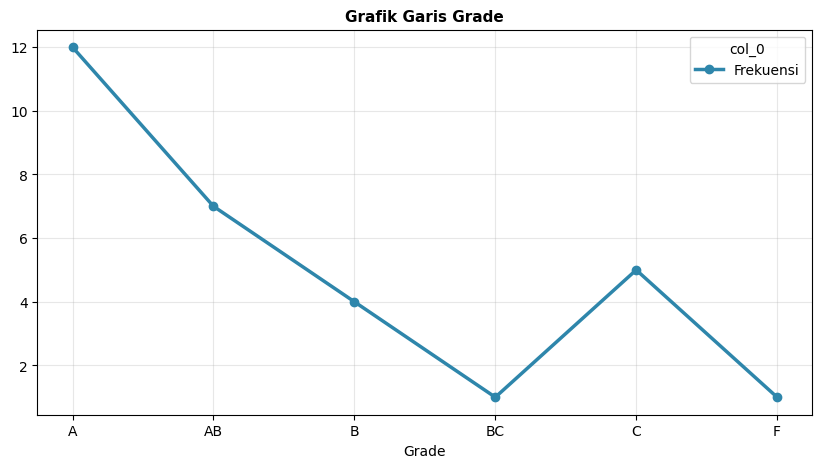

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
datafrq.plot(ax=ax, color='#2E86AB', marker='o', linewidth=2.5)
ax.set_title('Grafik Garis Grade', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.show()

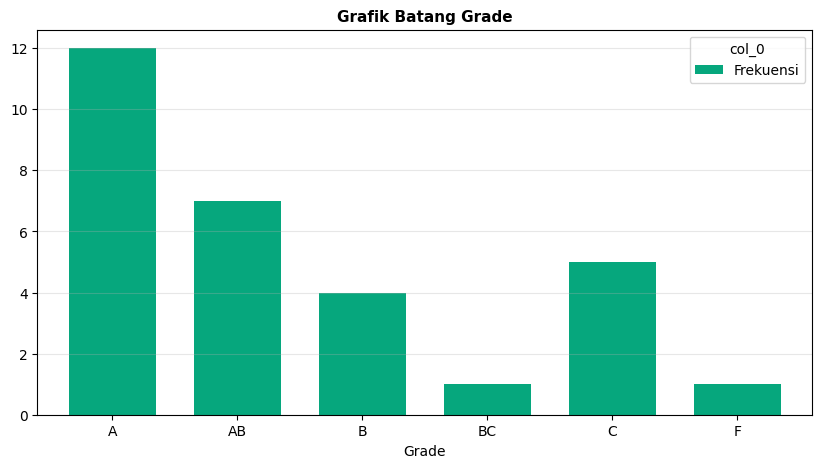

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#06A77D', '#D4A574', '#A23B72', '#F18F01', '#C73E1D', '#6A3E37']
datafrq.plot(kind='bar', ax=ax, color=colors, width=0.7)
ax.set_title('Grafik Batang Grade', fontsize=11, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.show()

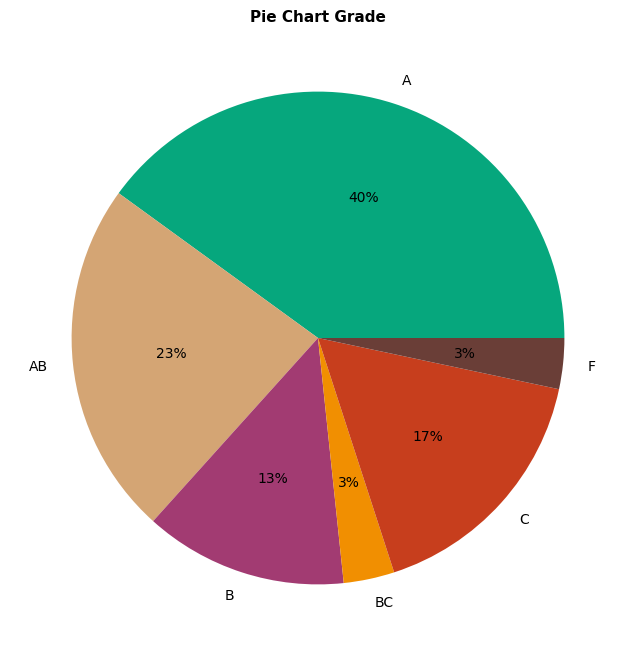

In [59]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#06A77D', '#D4A574', '#A23B72', '#F18F01', '#C73E1D', '#6A3E37']
datafrq.plot(kind='pie', y='Frekuensi', autopct='%1.0f%%', ax=ax, colors=colors, legend=False)
ax.set_title('Pie Chart Grade', fontsize=11, fontweight='bold')
ax.set_ylabel('')
plt.show()

In [64]:
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors='coerce')
dt = dataraw["Nilai"]
stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()

stats_df = pd.DataFrame({
    'Statistik': stats.index,
    'Nilai': stats.values
})

styled_stats = stats_df.style.background_gradient(cmap='RdBu')
display(styled_stats)

,Statistik,Nilai
0,count,30.000000
1,mean,76.221333
2,std,13.466585
3,min,46.010000
4,25%,68.095000
5,50%,78.800000
6,75%,87.040000
7,max,94.030000
8,Standard Error,2.458651
9,Median,78.800000
